In [2]:
import collections
import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

In [3]:
train_data,test_data=datasets.load_dataset("imdb",split=["train","test"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
train_data

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [5]:
test_data

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

In [6]:
train_data.features

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

**Tokenization**

In [7]:
max_length=256

In [8]:
def tokenizer(example):
  return {'tokens': example['text'].lower().split()[:max_length]}

In [9]:
train_data=train_data.map(tokenizer)
test_data=train_data.map(tokenizer)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

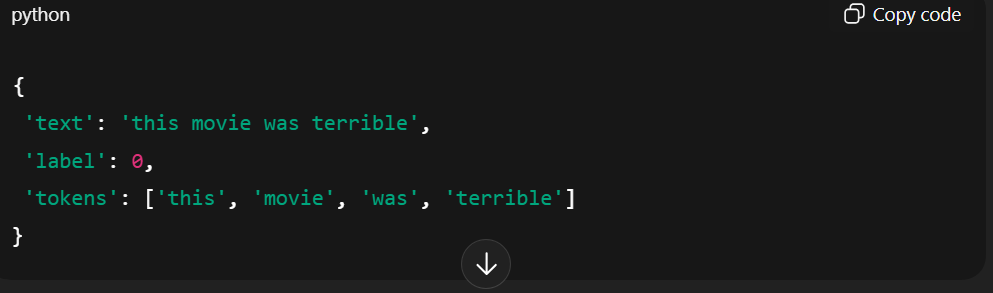

In [10]:
train_data

Dataset({
    features: ['text', 'label', 'tokens'],
    num_rows: 25000
})

### **Build Vocalbulary**

In [11]:
from collections import Counter
def build_vocabulary(dataset,min_freq):
  counter=Counter()
  for example in dataset:
    counter.update(example['tokens'])

  vocab={'<pad>':0,
         '<unk>':1}
  for word,freq in counter.items():
    if freq>=min_freq:
      vocab[word]=len(vocab)
  return vocab

In [12]:
vocab=build_vocabulary(
    dataset=train_data,
    min_freq=1
)

In [13]:
len(vocab)

212427

In [14]:
list(vocab.keys())[:10]

['<pad>',
 '<unk>',
 'i',
 'rented',
 'am',
 'curious-yellow',
 'from',
 'my',
 'video',
 'store']

### Convert tokens → indices

In [15]:
def numericalize(example):
  id=[]
  for token in example['tokens']:
    if token in vocab:
      id.append(vocab[token])
    else:
      id.append(vocab['<unk>'])
  example['input_ids']=id
  return example

In [16]:
train_data=train_data.map(numericalize)
test_data=test_data.map(numericalize)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [69]:
dataset = train_data.train_test_split(test_size=0.2, seed=42)

train_dataset = dataset["train"]

In [70]:
train_data

Dataset({
    features: ['text', 'label', 'tokens', 'input_ids'],
    num_rows: 25000
})

In [71]:
train_dataset

Dataset({
    features: ['text', 'label', 'tokens', 'input_ids'],
    num_rows: 20000
})

In [73]:
val_dataset

Dataset({
    features: ['text', 'label', 'tokens', 'input_ids'],
    num_rows: 5000
})

**Padding For DataLoader**

In [74]:
import torch

def collate_fn(batch):
    # batch = list of examples
    ids = [torch.tensor(x["input_ids"]) for x in batch]
    labels = [x["label"] for x in batch]

    # pad sequences
    ids = torch.nn.utils.rnn.pad_sequence(ids, batch_first=True, padding_value=0)
    labels = torch.tensor(labels)
    return {"input_ids": ids, "label": labels}


**DataLoader**

In [75]:
from torch.utils.data import DataLoader
train_loader=DataLoader(train_dataset,batch_size=512,shuffle=True,collate_fn=collate_fn,pin_memory=True)
test_loader=DataLoader(test_data,batch_size=512,shuffle=False,collate_fn=collate_fn,pin_memory=True)
val_loader=DataLoader(val_dataset,batch_size=512,shuffle=False,collate_fn=collate_fn,pin_memory=True)

In [76]:
len(train_loader)

40

In [77]:
len(test_loader)

49

In [78]:
len(val_loader)

10

### Build Model

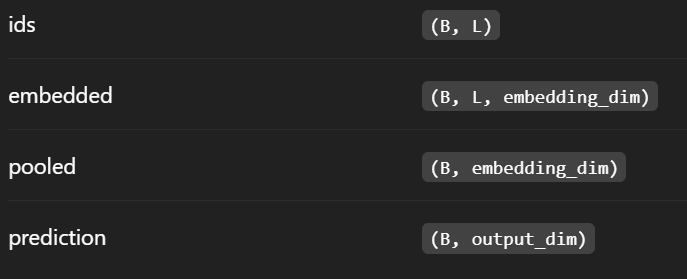

In [32]:
class NBoW(nn.Module):
  def __init__(self,vocab_size,embedding_dim,output_dim):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,embedding_dim,padding_idx=0)
    self.fc=nn.Linear(embedding_dim,output_dim)

  def forward(self,ids):
    embedded=self.embedding(ids)
    pooled=embedded.mean(dim=1)
    prediction=self.fc(pooled)
    return prediction

In [33]:
vocab_size=len(vocab)
embedding_dim=300
output_dim=len(train_data.unique("label"))
model=NBoW(vocab_size,embedding_dim,output_dim)

In [34]:
model

NBoW(
  (embedding): Embedding(212427, 300, padding_idx=0)
  (fc): Linear(in_features=300, out_features=2, bias=True)
)

In [37]:
model.embedding.weight.shape

torch.Size([212427, 300])

In [38]:
# 6B tokens, 300d vectors
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-12-25 09:14:21--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-12-25 09:14:22--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-12-25 09:14:23--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [39]:
def load_glove(path="glove.6B.300d.txt"):
    glove = {}
    with open(path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = torch.tensor([float(x) for x in values[1:]], dtype=torch.float)
            glove[word] = vector
    return glove

glove_vectors = load_glove("glove.6B.300d.txt")
print(len(glove_vectors))  # ~400k words


400000


**Create embedding matrix for my vocab**

In [40]:
vocab_size = len(vocab)
embedding_dim = 300

# Initialize random embedding
embedding_matrix = torch.randn(vocab_size, embedding_dim) * 0.01

# Fill with GloVe vectors if available
for word, idx in vocab.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]

In [41]:
model.embedding.weight

Parameter containing:
tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.1880,  0.4963,  0.6021,  ..., -1.0412, -0.1162,  0.7529],
        [-0.0364, -0.2139, -1.7814,  ...,  0.3703,  1.5169, -0.4448],
        ...,
        [ 0.2619, -0.1097,  0.4845,  ...,  0.1400,  0.7451, -1.7481],
        [-0.6713, -1.7651,  0.2567,  ..., -0.7616,  0.3020,  2.2259],
        [-1.5693, -1.4566,  1.2224,  ...,  0.1456,  1.9931, -1.4124]],
       requires_grad=True)

In [42]:
embedding_matrix

tensor([[-4.4455e-04, -5.4645e-03, -4.6112e-03,  ..., -1.2425e-02,
          7.3347e-03, -1.1458e-03],
        [-1.0042e-02,  1.4967e-02, -1.1315e-03,  ...,  1.2808e-03,
          4.8698e-03,  6.4527e-03],
        [-1.3292e-01,  1.6985e-01, -1.4360e-01,  ..., -2.3778e-01,
          1.4766e-01,  6.2902e-01],
        ...,
        [-7.9929e-02,  2.6862e-01, -2.4641e-02,  ...,  2.6438e-02,
          2.1415e-01, -5.3365e-01],
        [ 5.7355e-03,  1.5431e-02, -3.8373e-03,  ...,  4.2515e-04,
          5.6810e-03,  8.0378e-03],
        [-6.3029e-03, -1.0651e-02, -7.3702e-03,  ...,  1.1962e-02,
         -1.1082e-02, -3.8550e-03]])

In [43]:
model.embedding.weight.data.copy_(embedding_matrix)

tensor([[-4.4455e-04, -5.4645e-03, -4.6112e-03,  ..., -1.2425e-02,
          7.3347e-03, -1.1458e-03],
        [-1.0042e-02,  1.4967e-02, -1.1315e-03,  ...,  1.2808e-03,
          4.8698e-03,  6.4527e-03],
        [-1.3292e-01,  1.6985e-01, -1.4360e-01,  ..., -2.3778e-01,
          1.4766e-01,  6.2902e-01],
        ...,
        [-7.9929e-02,  2.6862e-01, -2.4641e-02,  ...,  2.6438e-02,
          2.1415e-01, -5.3365e-01],
        [ 5.7355e-03,  1.5431e-02, -3.8373e-03,  ...,  4.2515e-04,
          5.6810e-03,  8.0378e-03],
        [-6.3029e-03, -1.0651e-02, -7.3702e-03,  ...,  1.1962e-02,
         -1.1082e-02, -3.8550e-03]])

In [44]:
model.embedding.weight

Parameter containing:
tensor([[-4.4455e-04, -5.4645e-03, -4.6112e-03,  ..., -1.2425e-02,
          7.3347e-03, -1.1458e-03],
        [-1.0042e-02,  1.4967e-02, -1.1315e-03,  ...,  1.2808e-03,
          4.8698e-03,  6.4527e-03],
        [-1.3292e-01,  1.6985e-01, -1.4360e-01,  ..., -2.3778e-01,
          1.4766e-01,  6.2902e-01],
        ...,
        [-7.9929e-02,  2.6862e-01, -2.4641e-02,  ...,  2.6438e-02,
          2.1415e-01, -5.3365e-01],
        [ 5.7355e-03,  1.5431e-02, -3.8373e-03,  ...,  4.2515e-04,
          5.6810e-03,  8.0378e-03],
        [-6.3029e-03, -1.0651e-02, -7.3702e-03,  ...,  1.1962e-02,
         -1.1082e-02, -3.8550e-03]], requires_grad=True)

**Freeze the embeddings**

In [45]:
model.embedding.weight.requires_grad = False

In [46]:
optimizer=optim.Adam(model.parameters())

In [47]:
criterion=nn.CrossEntropyLoss()

In [48]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [49]:
model=model.to(device)
criterion=criterion.to(device)

In [50]:
def get_accuracy(prediction,label):
  batch_size,_=prediction.shape
  predicted_classes=prediction.argmax(dim=-1)
  correct_prediction=predicted_classes.eq(label).sum()
  accuracy=correct_prediction / batch_size
  return accuracy

In [56]:
def train(data_loader,model,criterion,optimizer,device):
  model.train()
  epoch_losses=[]
  epoch_accs=[]
  for batch  in tqdm.tqdm(data_loader,desc="training..."):
    ids=batch["input_ids"].to(device)
    label=batch["label"].to(device)
    prediction=model(ids)
    loss=criterion(prediction,label)
    accuracy=get_accuracy(prediction,label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())
    epoch_accs.append(accuracy.item())
  return np.mean(epoch_losses),np.mean(epoch_accs)

In [57]:
def evaluate(data_loader,model,criterion,device):
  model.eval()
  epoch_losses=[]
  epoch_accs=[]
  with torch.no_grad():
    for batch in tqdm.tqdm(data_loader,desc="evaluating..."):
      ids=batch["input_ids"].to(device)
      label=batch["label"].to(device)
      prediction=model(ids)
      loss=criterion(prediction,label)
      accuracy=get_accuracy(prediction,label)
      epoch_losses.append(loss.item())
      epoch_accs.append(accuracy.item())
    return np.mean(epoch_losses),np.mean(epoch_accs)



In [79]:
n_epochs=10
best_valid_loss=float("inf")
metrics=collections.defaultdict(list)
for epoch in range(n_epochs):
  train_loss,train_acc=train(train_loader,model,criterion,optimizer,device)
  valid_loss,valid_acc=evaluate(val_loader,model,criterion,device)
  metrics["train_losses"].append(train_loss)
  metrics["train_accs"].append(train_acc)
  metrics["valid_losses"].append(valid_loss)
  metrics["valid_acc"].append(valid_acc)
  if valid_loss <best_valid_loss:
    best_valid_loss=valid_loss
    torch.save(model.state_dict(),"nbow.pt")
  print(f"epoch:{epoch}")
  print(f"train_loss: {train_loss:.3f},train_acc: {train_acc:.3f}")
  print(f"valid_loss:{valid_loss:.3f},valid_acc: {valid_acc:3f}")

evaluating...: 100%|██████████| 10/10 [00:01<00:00,  6.11it/s]


epoch:0
train_loss: 0.686,train_acc: 0.620
valid_loss:0.677,valid_acc: 0.671074


evaluating...: 100%|██████████| 10/10 [00:01<00:00,  6.35it/s]


epoch:1
train_loss: 0.671,train_acc: 0.677
valid_loss:0.663,valid_acc: 0.702320


evaluating...: 100%|██████████| 10/10 [00:01<00:00,  6.25it/s]


...

epoch:7
train_loss: 0.619,train_acc: 0.710
valid_loss:0.613,valid_acc: 0.720783


evaluating...: 100%|██████████| 10/10 [00:02<00:00,  3.80it/s]


epoch:8
train_loss: 0.615,train_acc: 0.710
valid_loss:0.607,valid_acc: 0.730501


evaluating...: 100%|██████████| 10/10 [00:01<00:00,  6.20it/s]


epoch:9
train_loss: 0.609,train_acc: 0.717
valid_loss:0.602,valid_acc: 0.731222


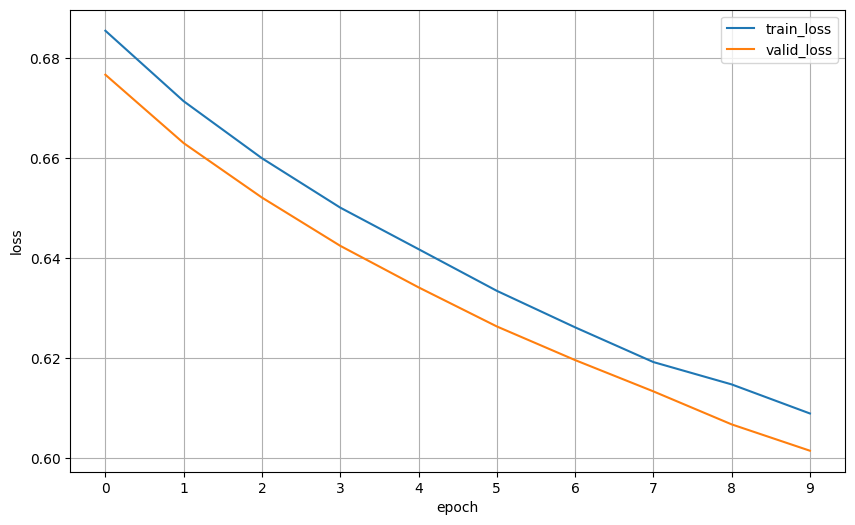

In [80]:
fig=plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.plot(metrics["train_losses"],label="train_loss")
ax.plot(metrics["valid_losses"],label="valid_loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

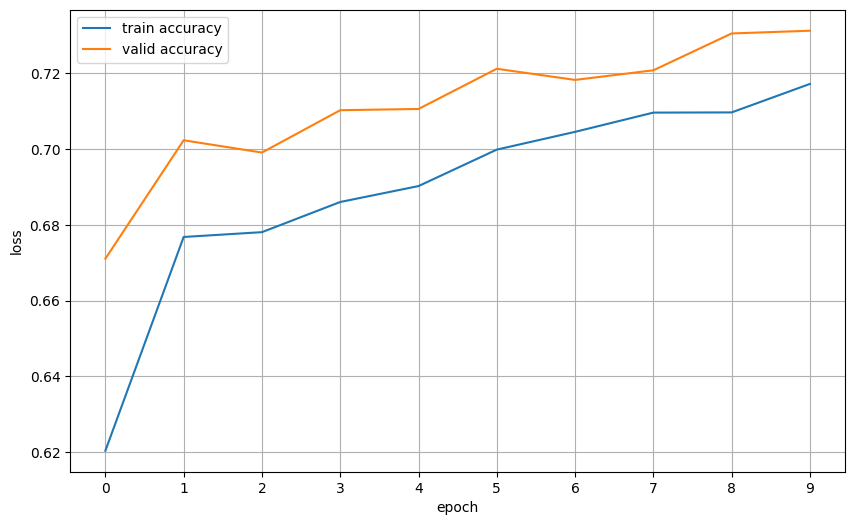

In [81]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_accs"], label="train accuracy")
ax.plot(metrics["valid_acc"], label="valid accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

In [82]:
model.load_state_dict(torch.load("nbow.pt"))
test_loss,test_acc=evaluate(test_loader,model,criterion,device)

evaluating...: 100%|██████████| 49/49 [00:08<00:00,  5.77it/s]


In [83]:
print(f"test_loss: {test_loss:.3f},test_acc:{test_acc:.3f}")

test_loss: 0.605,test_acc:0.722


**Predictive System**